(20640, 8)
(20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352 

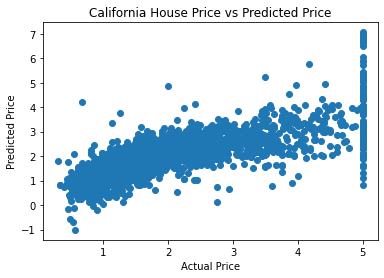

R-squared value on training dataset: 0.609
R-squared value on test dataset: 0.581
Mean Absolute Error: 0.542
Mean Squared Error: 0.559
Root Mean Squared Error: 0.748
10%% of Mean value of target: 0.207


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn import metrics

housing = datasets.fetch_california_housing()

print(housing.data.shape)
print(housing.target.shape)

print(housing.feature_names)

df = pd.DataFrame(housing.data, columns=housing.feature_names)
print(df.head())

df['PRICE'] = housing.target
print(df.head())

df.describe()

X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target,
    test_size=0.10, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.coef_)
print('Intercept: %.3f' % model.intercept_)

y_pred = model.predict(X_test)

print(y_pred[:5])
print(y_test[:5])

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('California House Price vs Predicted Price')
plt.show()

print('R-squared value on training dataset: %0.3f' % model.score(X_train, y_train))
print('R-squared value on test dataset: %0.3f' % model.score(X_test, y_test))
print('Mean Absolute Error: %0.3f' % metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: %0.3f' % metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %0.3f' % np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

print('10%% of Mean value of target: {:0.3f}'.format(np.mean(y_test)*0.1))
